In [1]:
# Cell 1: Setup and Configuration
import os
import shutil
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
# DATASET_DIR   = "dataset"
SPLIT_DIR     = "apple_dataset"          # train/val/test folders go here
CLASS_NAMES   = ["apple_leaf_healthy", "apple_rust_leaf", "apple_scab_leaf", "frogeye_leaf_spot", "mosaic", "powdery_mildew"]
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 16
EPOCHS        = 60
LEARNING_RATE = 1e-3    # Increased from 1e-4 to standard Adam default
CUTMIX_ALPHA  = 0.2     # Lowered from 1.0 (makes the CutMix boxes much smaller)
SEED          = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1779240082.294089  163489 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779240082.459553  163489 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779240084.170425  163489 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0
GPUs available: []


E0000 00:00:1779240087.301421  163489 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1779240087.301777  172594 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1779240087.320299  163489 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [2]:
# Cell 3: Load Datasets into tf.data.Dataset
def load_datasets():
    def make_ds(subset, shuffle):
        return keras.utils.image_dataset_from_directory(
            os.path.join(SPLIT_DIR, subset),
            image_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            label_mode="categorical",   # one-hot required for CutMix
            shuffle=shuffle,
            seed=SEED,
        )

    train_ds = make_ds("train", shuffle=True)
    val_ds   = make_ds("val",   shuffle=False)
    test_ds  = make_ds("test",  shuffle=False)
    return train_ds, val_ds, test_ds

# Load raw datasets
raw_train_ds, raw_val_ds, raw_test_ds = load_datasets()

Found 1043 files belonging to 6 classes.


Found 233 files belonging to 6 classes.
Found 232 files belonging to 6 classes.


In [3]:
# Cellule 5 : Preprocessing pour EfficientNet
augmentation_layer = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2), # Augmenté de 0.15 à 0.2
    layers.RandomZoom(0.2),     # Augmenté de 0.15 à 0.2
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1), # NOUVEAU
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
], name="data_augmentation")

def preprocess_train(images, labels):
    images = tf.cast(images, tf.float32) 
    # Attention : PAS de division par 255.0 ici !
    images = augmentation_layer(images, training=True)
    return images, labels

def preprocess_eval(images, labels):
    images = tf.cast(images, tf.float32) 
    # Attention : PAS de division par 255.0 ici !
    return images, labels

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (raw_train_ds
            .map(preprocess_train, num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))

val_ds   = (raw_val_ds
            .map(preprocess_eval,  num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE).cache())

test_ds  = (raw_test_ds
            .map(preprocess_eval,  num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE).cache())

In [4]:
# Cellule 6 : Modèle Avancé (EfficientNetB0)
def build_model(num_classes=3):
    # 1. Charger EfficientNetB0 pré-entraîné sur ImageNet
    base_model = keras.applications.EfficientNetB0(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )
    
    # 2. Dégeler le modèle pour le fine-tuning
    base_model.trainable = True
    
    # 3. Geler les premières couches (~237 couches au total, on en gèle 200)
    fine_tune_at = 236
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    
    # Les pixels bruts [0-255] entrent directement dans le modèle.
    # CRITIQUE : training=False maintient les statistiques de Batch Normalization intactes
    x = base_model(inputs, training=False) 
    
    from tensorflow.keras import regularizers

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.45)(x)
    # Ajout d'une régularisation L2 sur la couche finale
    outputs = layers.Dense(
        num_classes, 
        activation="softmax",
        kernel_regularizer=regularizers.l2(0.01) # Pénalité douce
    )(x)

    return keras.Model(inputs, outputs, name="AppleLeaf_EfficientNetB0")

model = build_model(num_classes=len(CLASS_NAMES))
model.summary()

Model: "AppleLeaf_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 10,246 (40.02 KB)

 Non-trainable params: 4,047,011 (15.44 MB)

In [5]:
# Cell 7: Callbacks and Plotting
def get_callbacks():
    return [
        keras.callbacks.ModelCheckpoint(
            "best_model.keras",
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=15,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=7,
            min_lr=1e-7,
            verbose=1,
        ),
    ]

def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history["accuracy"],     label="Train")
    axes[0].plot(history.history["val_accuracy"], label="Val")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history["loss"],     label="Train")
    axes[1].plot(history.history["val_loss"], label="Val")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# Cell 8: Compile and Train Model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks(),
)

# Plot the results once training is done
plot_history(history)

Epoch 1/60



══ Final Evaluation on Test Set ══
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 477ms/step - accuracy: 0.9649 - loss: 0.1850
Test Loss:     0.1850
Test Accuracy: 0.9649

── Classification Report ──
                   precision    recall  f1-score   support

frogeye_leaf_spot       0.90      1.00      0.95        38
           mosaic       1.00      0.97      0.99        38
   powdery_mildew       1.00      0.92      0.96        38

         accuracy                           0.96       114
        macro avg       0.97      0.96      0.97       114
     weighted avg       0.97      0.96      0.97       114



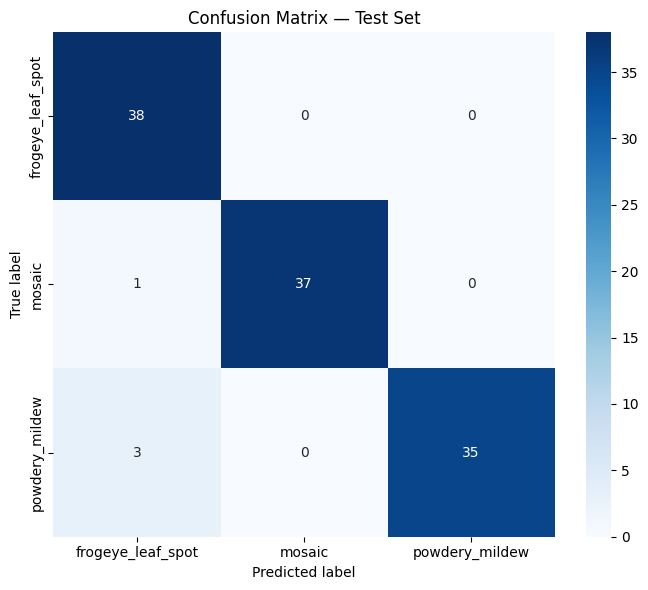


Model saved → apple_leaf_model_final.keras


In [12]:
# Cell 9: Evaluate on Held-Out Test Set & Save
def evaluate_test(model, test_ds):
    print("\n══ Final Evaluation on Test Set ══")
    test_loss, test_acc = model.evaluate(test_ds, verbose=1)
    print(f"Test Loss:     {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    y_true, y_pred = [], []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    print("\n── Classification Report ──")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.title("Confusion Matrix — Test Set")
    plt.tight_layout()
    plt.show()

# Run the final evaluation
evaluate_test(model, test_ds)

# Save the final model artifact
model.save("apple_leaf_model_final.keras")
print("\nModel saved → apple_leaf_model_final.keras")